# Unsupervised Learning for Asset Allocation

**AUTHOR**  
Rodrigo Kang

## Overview

This notebook accompanies the project **Unsupervised Learning for Asset Allocation** and contains the computational implementation supporting the methodology, experiments, and results discussed in the portfolio chapter.

The material presented here focuses on practical implementation details, including data preparation, model development, training procedures, evaluation workflows, and complementary computational experiments.

## Imports and Configuration

The analysis uses standard scientific Python libraries for data manipulation, statistical analysis, machine learning, and visualization. Portfolio construction and clustering procedures are implemented using publicly available open-source tools in order to maintain transparency and reproducibility throughout the workflow.

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Data acquisition
import yfinance as yf

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning and statistics
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# Plot configuration
plt.style.use("seaborn-v0_8")

## Asset Selection

The analysis uses a selection of large-cap U.S. equities from different sectors of the market. The objective is to work with assets that exhibit different correlation structures and risk profiles while remaining sufficiently liquid throughout the analyzed period.

The selected sample spans from January 2020 to December 2024 and includes different market environments, including the COVID-19 market shock and the subsequent recovery period.

In [2]:
tickers = [
    "AAPL",   # Technology
    "MSFT",   # Technology
    "GOOGL",  # Communication Services
    "AMZN",   # Consumer Discretionary
    "META",   # Communication Services
    "JPM",    # Financials
    "BAC",    # Financials
    "XOM",    # Energy
    "CVX",    # Energy
    "JNJ",    # Healthcare
    "PFE",    # Healthcare
    "PG",     # Consumer Staples
    "KO",     # Consumer Staples
    "WMT",    # Retail
    "HD"      # Consumer Discretionary
]

start_date = "2020-01-01"
end_date = "2024-12-31"

len(tickers)

15

## Data Collection

Daily adjusted closing prices are downloaded from Yahoo Finance using the `yfinance` library. Adjusted prices are used throughout the analysis in order to account for stock splits and dividend adjustments when available.

The downloaded series are aligned by trading date and combined into a single dataset before return calculation.

In [3]:
price_data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)["Close"]

price_data = price_data.dropna()

price_data.head()

Ticker,AAPL,AMZN,BAC,CVX,GOOGL,HD,JNJ,JPM,KO,META,MSFT,PFE,PG,WMT,XOM
Date,,,,,,,,,,,,,,,
2020-01-02,72.333878,94.900497,30.587561,91.182571,67.873024,188.727661,121.936981,118.430313,45.432701,208.146576,151.829559,27.048357,104.735359,36.289959,52.947033
2020-01-03,71.630630,93.748497,29.952461,90.867203,67.517960,188.100479,120.525192,116.867470,45.184849,207.045212,149.938965,26.903236,104.030945,35.969593,52.521358
2020-01-06,72.201408,95.143997,29.909555,90.559326,69.317596,188.985382,120.374878,116.774574,45.168316,210.944626,150.326569,26.868689,104.175232,35.896370,52.924629
2020-01-07,71.861839,95.343002,29.712149,89.402916,69.183685,187.748169,121.109978,114.789330,44.821320,211.401016,148.955948,26.778843,103.530220,35.563789,52.491497
2020-01-08,73.017853,94.598503,30.012537,88.381714,69.676132,190.557693,121.093254,115.684799,44.903938,213.544220,151.328522,26.993076,103.971550,35.441746,51.699905


## Return Calculation

Daily simple returns are computed from the adjusted closing prices and used throughout the analysis. The resulting return matrix forms the basis for the covariance estimation, PCA decomposition, clustering procedures, and portfolio construction stages developed later in the notebook.

In [4]:
returns = price_data.pct_change().dropna()

returns.head()

Ticker,AAPL,AMZN,BAC,CVX,GOOGL,HD,JNJ,JPM,KO,META,MSFT,PFE,PG,WMT,XOM
Date,,,,,,,,,,,,,,,
2020-01-03,-0.009722,-0.012139,-0.020763,-0.003459,-0.005231,-0.003323,-0.011578,-0.013196,-0.005455,-0.005291,-0.012452,-0.005365,-0.006726,-0.008828,-0.008040
2020-01-06,0.007968,0.014886,-0.001432,-0.003388,0.026654,0.004704,-0.001247,-0.000795,-0.000366,0.018834,0.002585,-0.001284,0.001387,-0.002036,0.007678
2020-01-07,-0.004703,0.002092,-0.006600,-0.012770,-0.001932,-0.006547,0.006107,-0.017001,-0.007682,0.002164,-0.009118,-0.003344,-0.006192,-0.009265,-0.008184
2020-01-08,0.016087,-0.007809,0.010110,-0.011422,0.007118,0.014964,-0.000138,0.007801,0.001843,0.010138,0.015928,0.008000,0.004263,-0.003432,-0.015080
2020-01-09,0.021240,0.004799,0.001716,-0.001615,0.010498,0.015330,0.002966,0.003651,0.018215,0.014311,0.012493,-0.004352,0.010938,0.010331,0.007656


## Price and Return Series

Before applying the portfolio construction methods, the price and return series are inspected in order to obtain a preliminary view of the market behaviour during the analyzed period.

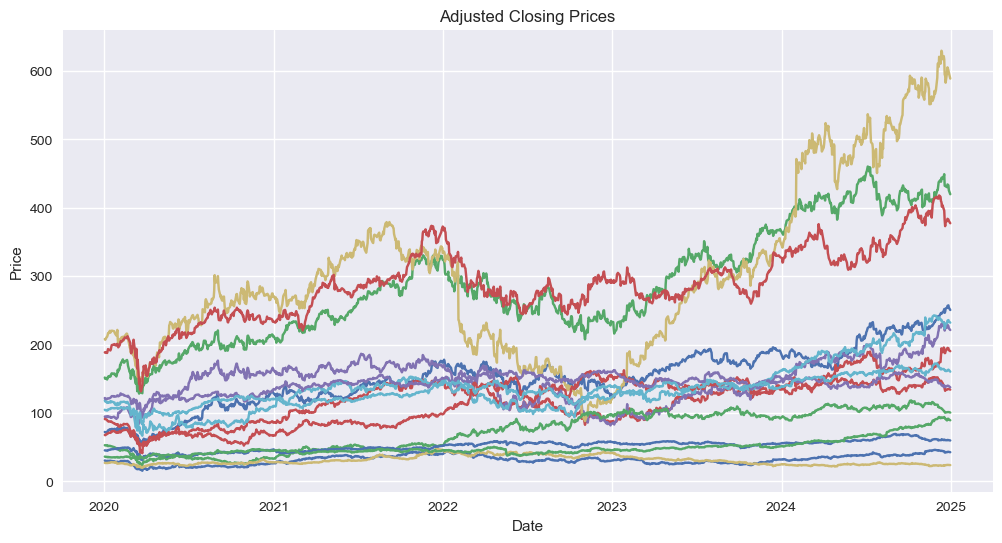

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

for ticker in tickers:
    ax.plot(price_data.index, price_data[ticker], label=ticker)

ax.set_title("Adjusted Closing Prices")
ax.set_xlabel("Date")
ax.set_ylabel("Price")

plt.show()

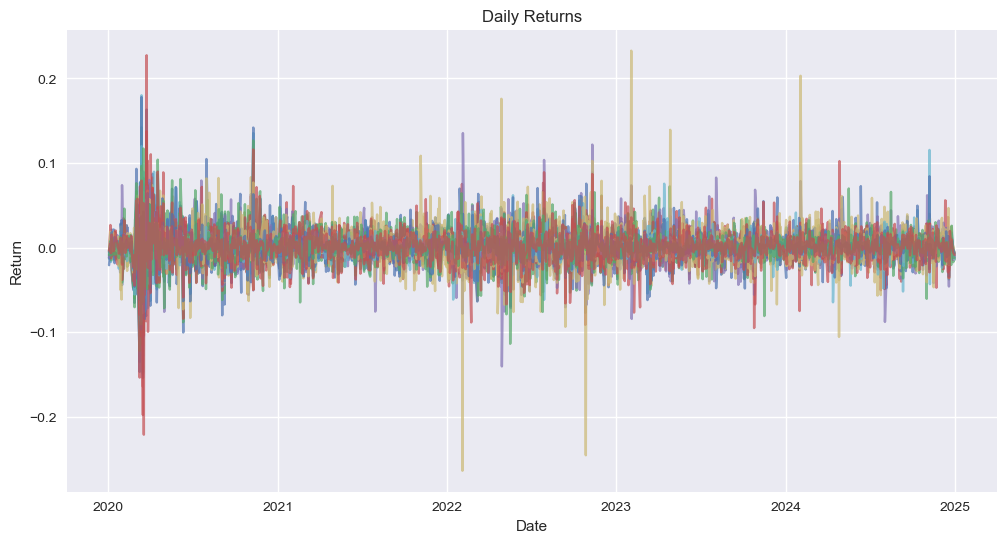

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

for ticker in tickers:
    ax.plot(returns.index, returns[ticker], alpha=0.7)

ax.set_title("Daily Returns")
ax.set_xlabel("Date")
ax.set_ylabel("Return")

plt.show()

## Correlation Structure

The correlation matrix provides a first view of the dependency structure between assets. Highly correlated groups may indicate exposure to common underlying drivers, while weaker correlations can contribute to diversification within the portfolio.

In [7]:
correlation_matrix = returns.corr()

correlation_matrix.head()

Ticker,AAPL,AMZN,BAC,CVX,GOOGL,HD,JNJ,JPM,KO,META,MSFT,PFE,PG,WMT,XOM
Ticker,,,,,,,,,,,,,,,
AAPL,1.000000,0.592143,0.413447,0.334219,0.648873,0.556472,0.374567,0.410468,0.440102,0.563061,0.748290,0.285415,0.429187,0.363235,0.282180
AMZN,0.592143,1.000000,0.282779,0.163671,0.647135,0.425302,0.179460,0.266027,0.220203,0.608941,0.678451,0.164951,0.231732,0.296711,0.131008
BAC,0.413447,0.282779,1.000000,0.635572,0.408402,0.511261,0.409901,0.894937,0.516473,0.312640,0.422180,0.322234,0.381629,0.255636,0.595856
CVX,0.334219,0.163671,0.635572,1.000000,0.331727,0.425073,0.373650,0.633420,0.453103,0.210479,0.331673,0.277799,0.249035,0.188189,0.855425
GOOGL,0.648873,0.647135,0.408402,0.331727,1.000000,0.476387,0.296807,0.402769,0.369831,0.640922,0.746133,0.252796,0.335103,0.293635,0.259991


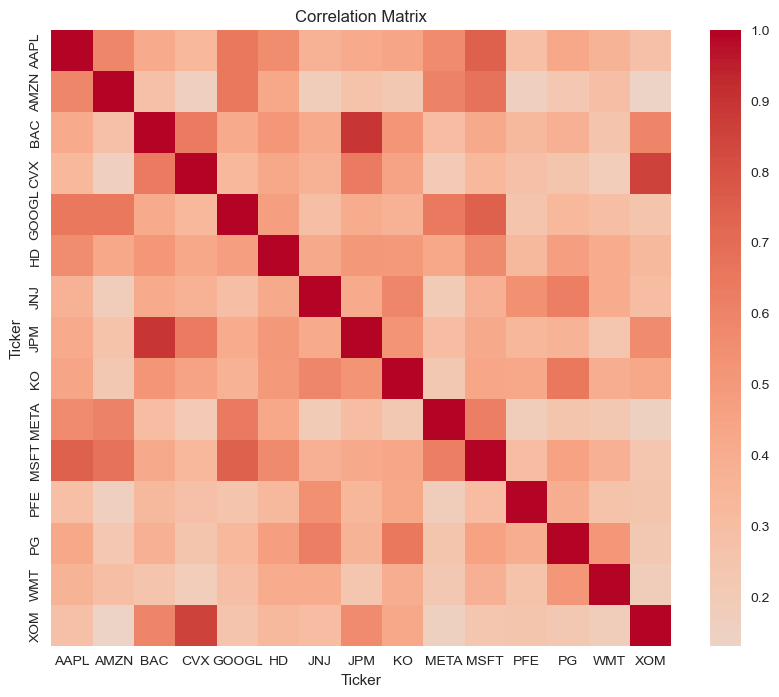

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=False,
    ax=ax
)

ax.set_title("Correlation Matrix")

plt.show()

## Covariance Matrix

The covariance matrix summarizes how asset returns vary jointly through time and serves as the main input for the PCA decomposition and the portfolio allocation procedures developed later in the notebook.

In [9]:
covariance_matrix = returns.cov()

covariance_matrix.head()

Ticker,AAPL,AMZN,BAC,CVX,GOOGL,HD,JNJ,JPM,KO,META,MSFT,PFE,PG,WMT,XOM
Ticker,,,,,,,,,,,,,,,
AAPL,0.000398,0.000268,0.000186,0.000150,0.000265,0.000202,0.000093,0.000168,0.000115,0.000318,0.000287,0.000099,0.000113,0.000103,0.000122
AMZN,0.000268,0.000514,0.000144,0.000083,0.000300,0.000175,0.000050,0.000124,0.000065,0.000390,0.000295,0.000065,0.000069,0.000096,0.000064
BAC,0.000186,0.000144,0.000507,0.000321,0.000188,0.000209,0.000114,0.000413,0.000152,0.000199,0.000183,0.000126,0.000113,0.000082,0.000291
CVX,0.000150,0.000083,0.000321,0.000503,0.000152,0.000173,0.000104,0.000291,0.000133,0.000134,0.000143,0.000108,0.000074,0.000060,0.000415
GOOGL,0.000265,0.000300,0.000188,0.000152,0.000419,0.000177,0.000075,0.000169,0.000099,0.000371,0.000294,0.000090,0.000090,0.000086,0.000115


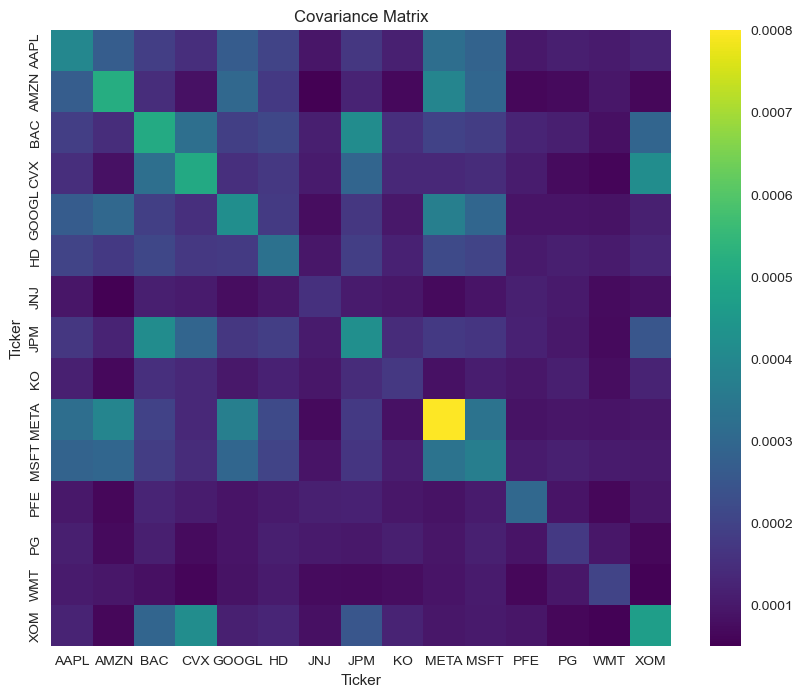

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    covariance_matrix,
    cmap="viridis",
    annot=False,
    ax=ax
)

ax.set_title("Covariance Matrix")

plt.show()

## Principal Component Analysis

Principal Component Analysis (PCA) is used to study the dominant sources of variation in the covariance structure of the market. The decomposition allows the analysis to identify how much of the total variance is explained by a reduced number of orthogonal components.

In [11]:
pca = PCA()

pca.fit(returns)

PCA()

In [12]:
explained_variance = pca.explained_variance_ratio_

explained_variance

array([0.4637684 , 0.17930777, 0.07396985, 0.05117435, 0.04661145,
       0.03521787, 0.02972032, 0.02621717, 0.02295568, 0.01809235,
       0.01435495, 0.01227028, 0.01020065, 0.00843601, 0.00770291])

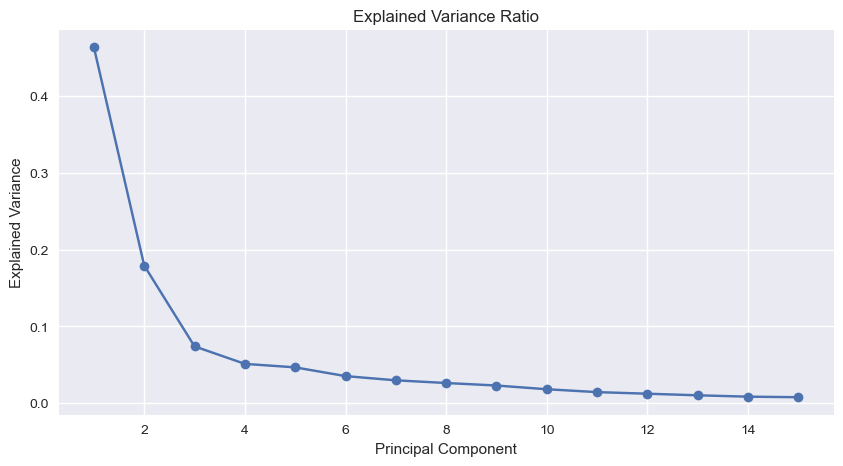

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker="o"
)

ax.set_title("Explained Variance Ratio")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance")

plt.show()

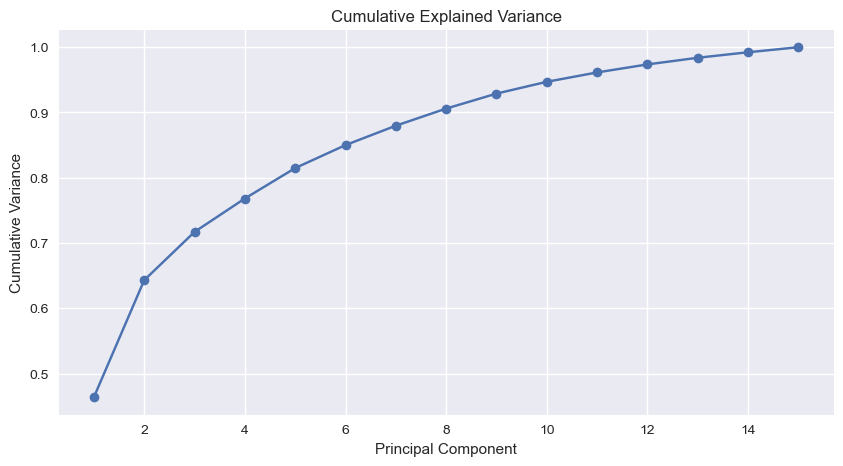

In [14]:
cumulative_variance = explained_variance.cumsum()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

ax.set_title("Cumulative Explained Variance")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Cumulative Variance")

plt.show()

## Principal Components

The principal components can be interpreted as orthogonal directions of market variation. Examining the component loadings provides a view of how individual assets contribute to each source of risk identified by the PCA decomposition.

In [15]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=returns.columns,
    columns=[
        f"PC{i+1}" for i in range(len(returns.columns))
    ]
)

loadings.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15
Ticker,,,,,,,,,,,,,,,
AAPL,0.298186,0.161817,0.140168,-0.198153,-0.154454,-0.167970,-0.435559,0.126829,0.662252,0.162292,-0.276844,0.149015,0.008768,0.065036,-0.007148
AMZN,0.291602,0.354813,-0.078332,-0.178976,-0.448625,0.374651,0.572521,0.037486,0.100130,-0.225648,-0.079321,0.095708,0.030769,0.050877,0.012791
BAC,0.328027,-0.316583,-0.037027,0.520661,-0.225358,0.062854,0.020641,-0.083766,0.065801,0.064082,-0.033339,-0.090133,-0.326469,0.094671,-0.569489
CVX,0.284361,-0.415487,-0.281729,-0.358317,0.112574,-0.032748,0.002889,0.092721,-0.098727,-0.000234,0.284608,0.474322,0.234180,0.348708,-0.155654
GOOGL,0.306589,0.213532,-0.049581,-0.120909,-0.131547,0.177663,-0.434919,-0.258393,-0.629364,0.126318,-0.341699,0.070503,-0.055188,0.027359,0.031006


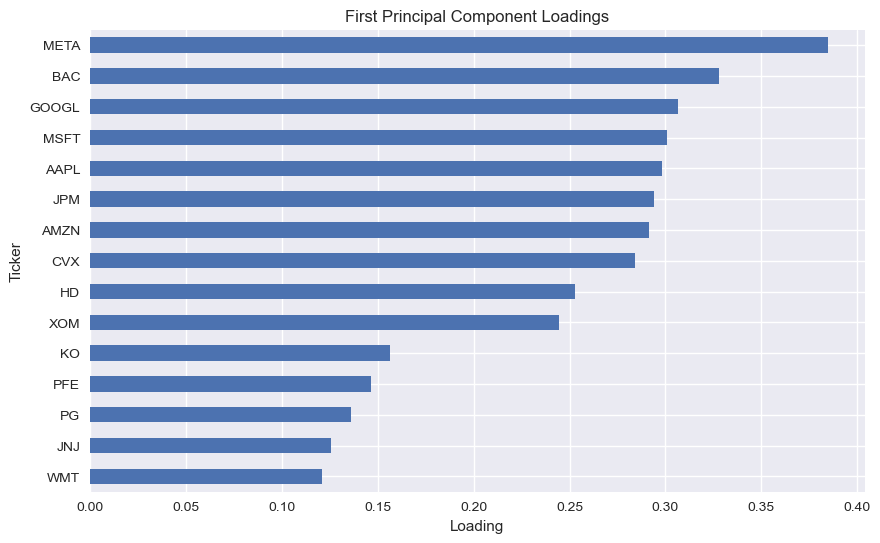

In [16]:
pc1_loadings = loadings["PC1"].sort_values()

fig, ax = plt.subplots(figsize=(10, 6))

pc1_loadings.plot(
    kind="barh",
    ax=ax
)

ax.set_title("First Principal Component Loadings")
ax.set_xlabel("Loading")

plt.show()

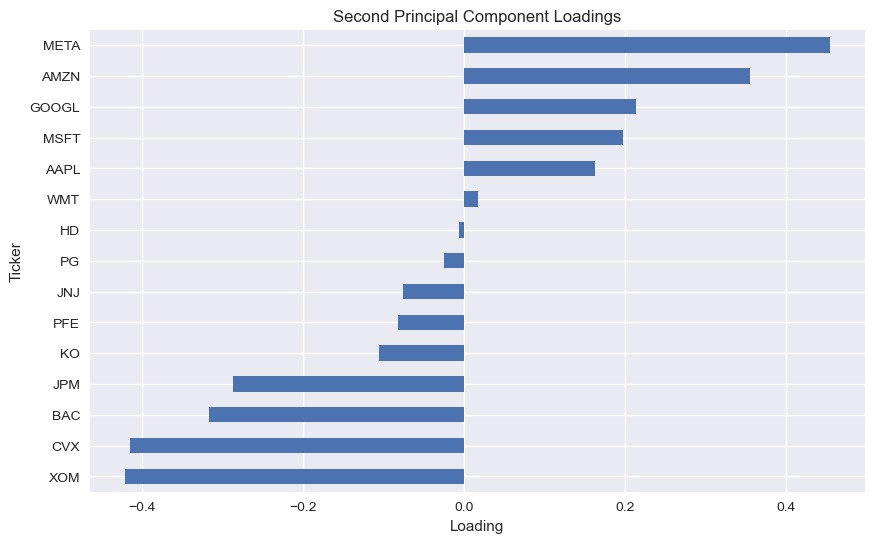

In [17]:
pc2_loadings = loadings["PC2"].sort_values()

fig, ax = plt.subplots(figsize=(10, 6))

pc2_loadings.plot(
    kind="barh",
    ax=ax
)

ax.set_title("Second Principal Component Loadings")
ax.set_xlabel("Loading")

plt.show()

## Hierarchical Clustering

Hierarchical clustering is used to identify groups of assets with similar correlation patterns. The clustering procedure is based on a correlation-derived distance matrix and produces a hierarchical representation of the dependency structure across the market.

In [18]:
distance_matrix = np.sqrt(
    0.5 * (1 - correlation_matrix)
)

distance_matrix.head()

Ticker,AAPL,AMZN,BAC,CVX,GOOGL,HD,JNJ,JPM,KO,META,MSFT,PFE,PG,WMT,XOM
Ticker,,,,,,,,,,,,,,,
AAPL,0.000000,0.451584,0.541550,0.576967,0.419003,0.470918,0.559211,0.542924,0.529102,0.467407,0.354761,0.597740,0.534234,0.564254,0.599091
AMZN,0.451584,0.000000,0.598841,0.646656,0.420039,0.536049,0.640523,0.605794,0.624419,0.442187,0.400967,0.646161,0.619785,0.592996,0.659163
BAC,0.541550,0.598841,0.000000,0.426865,0.543874,0.494337,0.543184,0.229197,0.491695,0.586242,0.537503,0.582136,0.556045,0.610067,0.449524
CVX,0.576967,0.646656,0.426865,0.000000,0.578045,0.536156,0.559620,0.428124,0.522923,0.628300,0.578069,0.600916,0.612766,0.637107,0.268864
GOOGL,0.419003,0.420039,0.543874,0.578045,0.000000,0.511670,0.592956,0.546457,0.561324,0.423720,0.356277,0.611230,0.576583,0.594292,0.608280


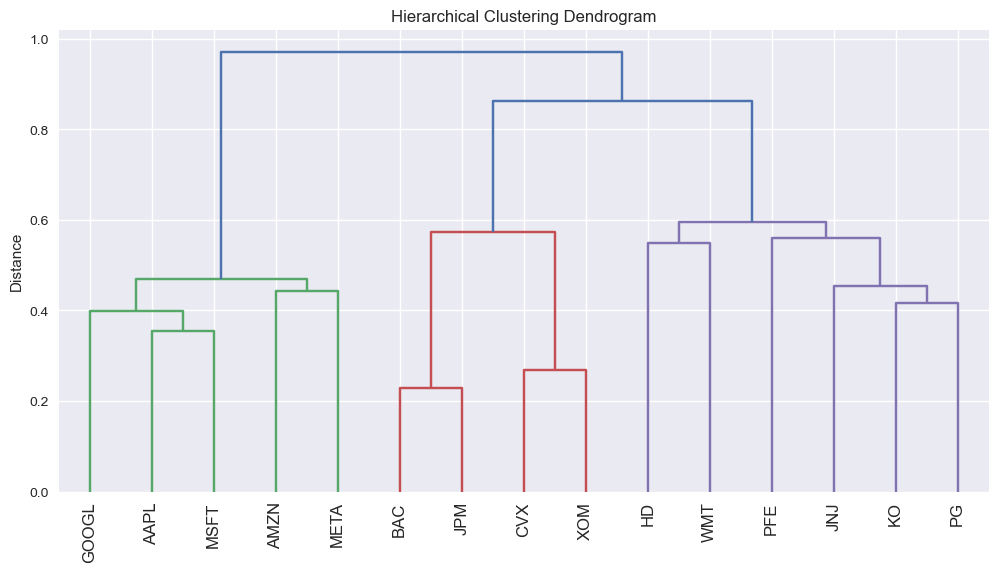

In [19]:
linkage_matrix = linkage(
    squareform(distance_matrix),
    method="ward"
)

fig, ax = plt.subplots(figsize=(12, 6))

dendrogram(
    linkage_matrix,
    labels=returns.columns,
    leaf_rotation=90,
    ax=ax
)

ax.set_title("Hierarchical Clustering Dendrogram")
ax.set_ylabel("Distance")

plt.show()

## Clustered Correlation Matrix

The dendrogram provides an ordering of the assets based on their hierarchical relationships. Reordering the correlation matrix using this structure makes the clustered behaviour easier to inspect visually.

In [20]:
dendrogram_info = dendrogram(
    linkage_matrix,
    labels=returns.columns,
    no_plot=True
)

ordered_tickers = dendrogram_info["ivl"]

ordered_correlation_matrix = correlation_matrix.loc[
    ordered_tickers,
    ordered_tickers
]

ordered_correlation_matrix.head()

Ticker,GOOGL,AAPL,MSFT,AMZN,META,BAC,JPM,CVX,XOM,HD,WMT,PFE,JNJ,KO,PG
Ticker,,,,,,,,,,,,,,,
GOOGL,1.000000,0.648873,0.746133,0.647135,0.640922,0.408402,0.402769,0.331727,0.259991,0.476387,0.293635,0.252796,0.296807,0.369831,0.335103
AAPL,0.648873,1.000000,0.748290,0.592143,0.563061,0.413447,0.410468,0.334219,0.282180,0.556472,0.363235,0.285415,0.374567,0.440102,0.429187
MSFT,0.746133,0.748290,1.000000,0.678451,0.619754,0.422180,0.421323,0.331673,0.242462,0.576451,0.379103,0.312642,0.379367,0.434317,0.455138
AMZN,0.647135,0.592143,0.678451,1.000000,0.608941,0.282779,0.266027,0.163671,0.131008,0.425302,0.296711,0.164951,0.179460,0.220203,0.231732
META,0.640922,0.563061,0.619754,0.608941,1.000000,0.312640,0.302579,0.210479,0.154290,0.423900,0.220513,0.179384,0.196293,0.224841,0.245627


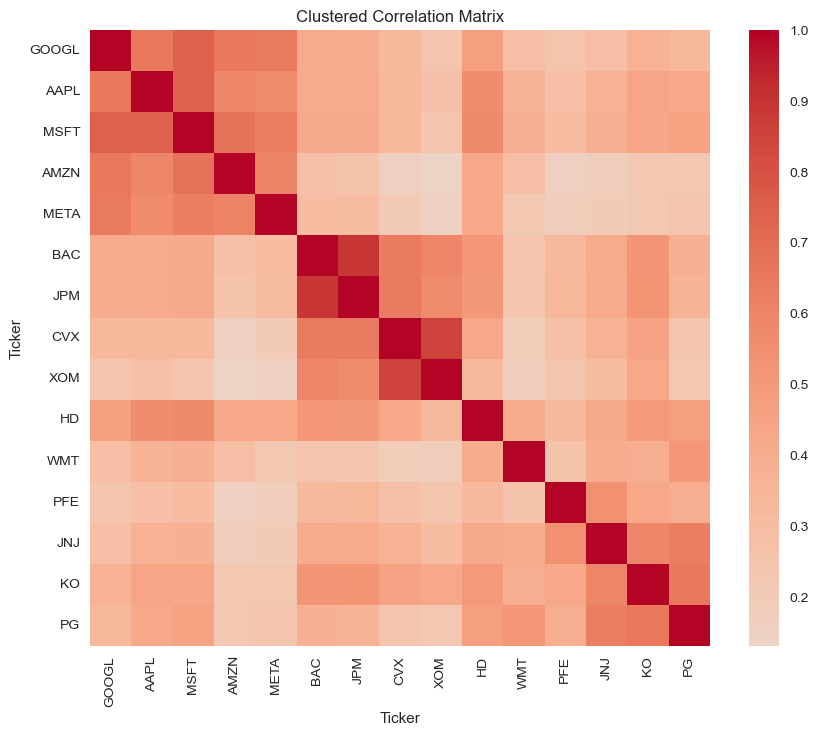

In [21]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    ordered_correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=False,
    ax=ax
)

ax.set_title("Clustered Correlation Matrix")

plt.show()

## Hierarchical Risk Parity

The final portfolio allocation is constructed using a Hierarchical Risk Parity (HRP) approach. The allocation process distributes portfolio weights across the hierarchical structure identified by the clustering stage, reducing concentration in highly correlated groups of assets.

In [22]:
def get_cluster_var(cov, cluster_items):
    """
    Computes the variance of a cluster of assets using
    equally weighted allocations within the cluster.

    Inputs
    ------
    cov : pandas.DataFrame
        Covariance matrix of asset returns.

    cluster_items : list
        List containing the assets that belong to
        the cluster.

    Outputs
    -------
    cluster_var : float
        Estimated variance of the cluster.

    Author
    ------
    Rodrigo Kang
    """

    cluster_cov = cov.loc[cluster_items, cluster_items]

    weights = np.ones(len(cluster_items))
    weights = weights / weights.sum()

    cluster_var = np.dot(
        weights.T,
        np.dot(cluster_cov, weights)
    )

    return cluster_var

In [23]:
def hrp_allocation(cov, ordered_assets):
    """
    Computes Hierarchical Risk Parity (HRP) portfolio
    weights using recursive bisection.

    Inputs
    ------
    cov : pandas.DataFrame
        Covariance matrix of asset returns.

    ordered_assets : list
        List of assets ordered according to the
        hierarchical clustering structure.

    Outputs
    -------
    weights : pandas.Series
        Portfolio weights obtained from the HRP
        allocation procedure.

    Author
    ------
    Rodrigo Kang
    """

    weights = pd.Series(
        1.0,
        index=ordered_assets
    )

    clusters = [ordered_assets]

    while len(clusters) > 0:
        cluster = clusters.pop(0)

        if len(cluster) <= 1:
            continue

        split = len(cluster) // 2

        cluster_left = cluster[:split]
        cluster_right = cluster[split:]

        var_left = get_cluster_var(cov, cluster_left)
        var_right = get_cluster_var(cov, cluster_right)

        alpha = 1 - var_left / (var_left + var_right)

        weights[cluster_left] *= alpha
        weights[cluster_right] *= (1 - alpha)

        clusters.append(cluster_left)
        clusters.append(cluster_right)

    return weights

In [24]:
hrp_weights = hrp_allocation(
    covariance_matrix,
    ordered_tickers
)

hrp_weights

GOOGL    0.070504
AAPL     0.042390
MSFT     0.045740
AMZN     0.043898
META     0.028163
BAC      0.038994
JPM      0.047085
CVX      0.035997
XOM      0.038558
HD       0.068913
WMT      0.112673
PFE      0.065737
JNJ      0.128452
KO       0.117141
PG       0.115756
dtype: float64

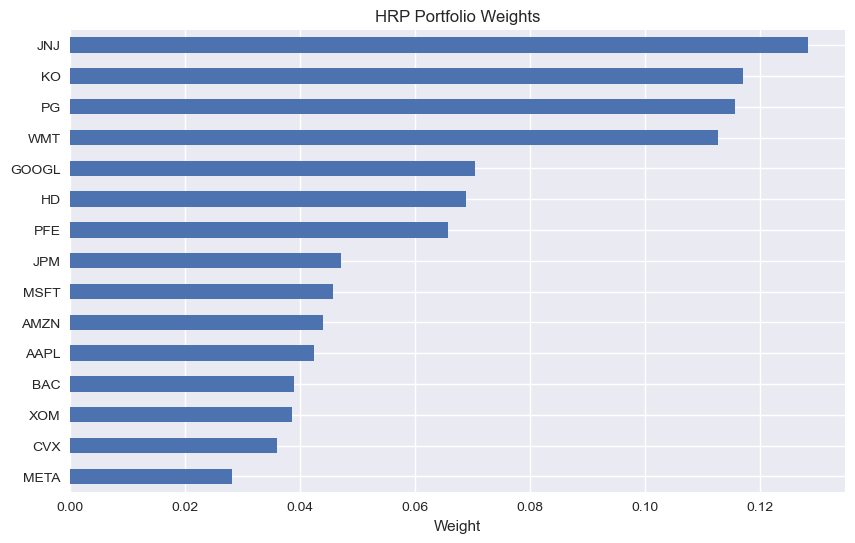

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

hrp_weights.sort_values().plot(
    kind="barh",
    ax=ax
)

ax.set_title("HRP Portfolio Weights")
ax.set_xlabel("Weight")

plt.show()

## Benchmark Portfolio

An equally weighted portfolio is used as a benchmark for comparison. Although simple, the $1/N$ allocation provides a useful reference point for evaluating whether the HRP allocation produces meaningful differences in diversification and portfolio concentration.

In [26]:
equal_weights = pd.Series(
    1 / len(tickers),
    index=tickers
)

equal_weights

AAPL     0.066667
MSFT     0.066667
GOOGL    0.066667
AMZN     0.066667
META     0.066667
JPM      0.066667
BAC      0.066667
XOM      0.066667
CVX      0.066667
JNJ      0.066667
PFE      0.066667
PG       0.066667
KO       0.066667
WMT      0.066667
HD       0.066667
dtype: float64

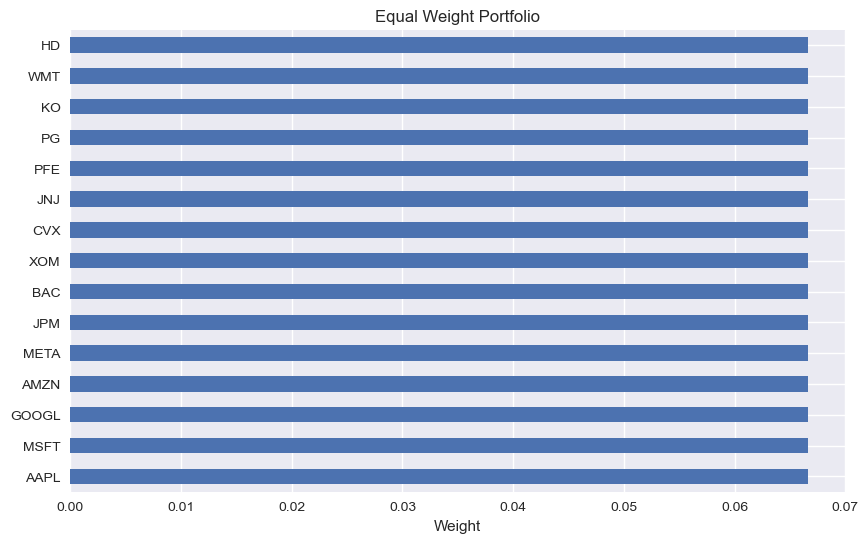

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

equal_weights.sort_values().plot(
    kind="barh",
    ax=ax
)

ax.set_title("Equal Weight Portfolio")
ax.set_xlabel("Weight")

plt.show()

In [28]:
weights_comparison = pd.DataFrame({
    "Equal Weight": equal_weights,
    "HRP": hrp_weights
})

weights_comparison

,Equal Weight,HRP
AAPL,0.066667,0.042390
AMZN,0.066667,0.043898
BAC,0.066667,0.038994
CVX,0.066667,0.035997
GOOGL,0.066667,0.070504
HD,0.066667,0.068913
JNJ,0.066667,0.128452
JPM,0.066667,0.047085
KO,0.066667,0.117141
META,0.066667,0.028163


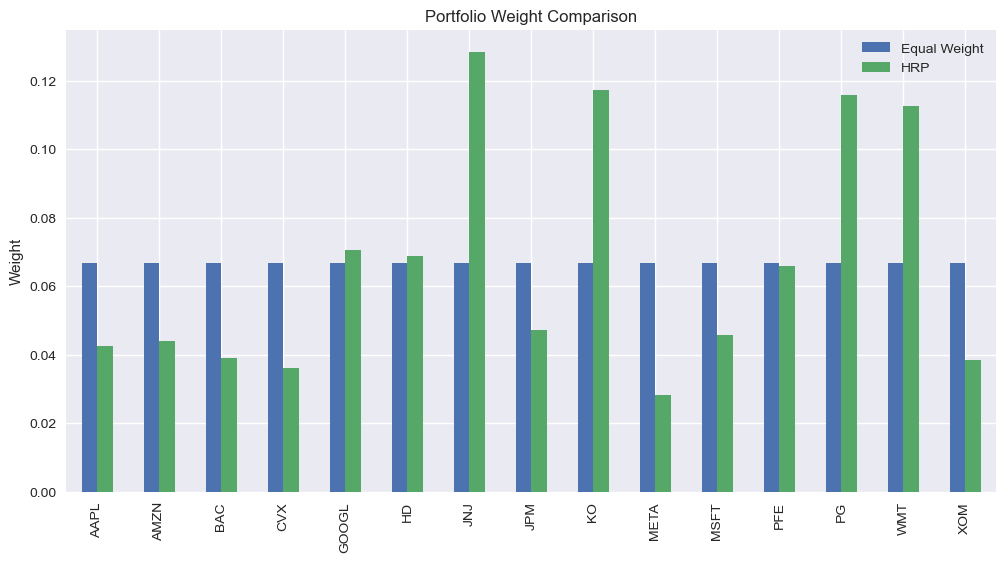

In [29]:
weights_comparison.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Portfolio Weight Comparison")
plt.ylabel("Weight")

plt.show()

## Portfolio Performance

The performance of the HRP and equal weight portfolios is evaluated using daily portfolio returns. The comparison focuses on basic risk and return metrics that provide a compact view of portfolio behaviour over the analyzed period.

In [30]:
portfolio_returns = pd.DataFrame({
    "Equal Weight": returns.dot(equal_weights),
    "HRP": returns.dot(hrp_weights)
})

portfolio_returns.head()

,Equal Weight,HRP
Date,,
2020-01-03,-0.008771,-0.008379
2020-01-06,0.004943,0.003568
2020-01-07,-0.005532,-0.004980
2020-01-08,0.003891,0.003486
2020-01-09,0.008545,0.009017


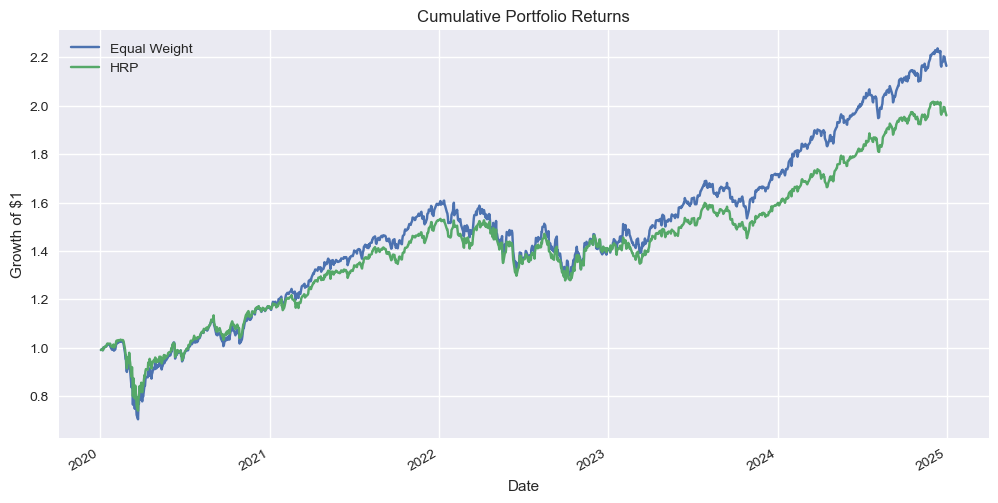

In [31]:
cumulative_returns = (1 + portfolio_returns).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))

cumulative_returns.plot(ax=ax)

ax.set_title("Cumulative Portfolio Returns")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")

plt.show()

In [32]:
performance_summary = pd.DataFrame({
    "Annualized Return": portfolio_returns.mean() * 252,
    "Annualized Volatility": portfolio_returns.std() * np.sqrt(252),
    "Sharpe Ratio": (
        portfolio_returns.mean() * 252
    ) / (
        portfolio_returns.std() * np.sqrt(252)
    ),
    "Maximum Drawdown": (
        cumulative_returns / cumulative_returns.cummax() - 1
    ).min()
})

performance_summary

,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
Equal Weight,0.175402,0.202078,0.867990,-0.313892
HRP,0.151399,0.180810,0.837339,-0.283128


## Rolling Volatility

Rolling volatility is computed in order to compare how portfolio risk evolves through time under the two allocation schemes. This provides a simple view of how the portfolios behave across different market environments.

In [33]:
rolling_volatility = (
    portfolio_returns
    .rolling(window=60)
    .std()
    * np.sqrt(252)
)

rolling_volatility.head()

,Equal Weight,HRP
Date,,
2020-01-03,NaN,NaN
2020-01-06,NaN,NaN
2020-01-07,NaN,NaN
2020-01-08,NaN,NaN
2020-01-09,NaN,NaN


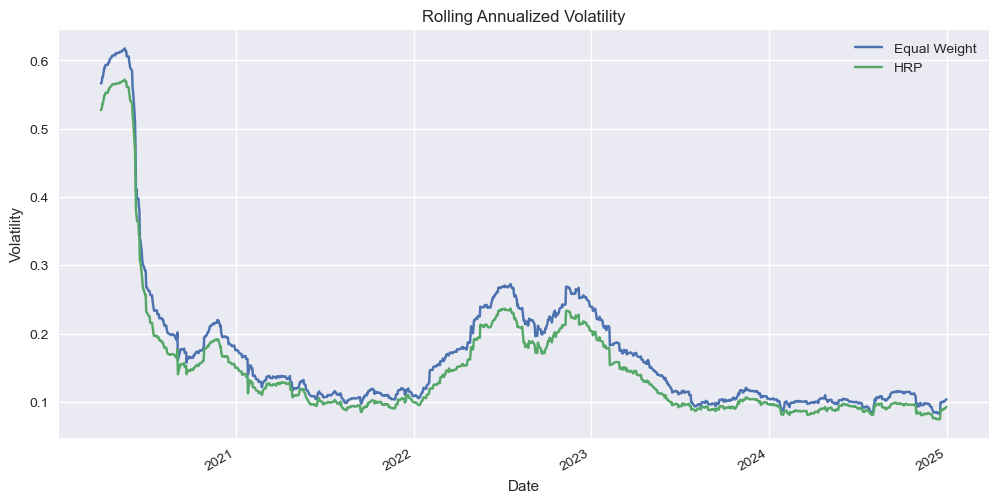

In [34]:
fig, ax = plt.subplots(figsize=(12, 6))

rolling_volatility.plot(ax=ax)

ax.set_title("Rolling Annualized Volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Volatility")

plt.show()

## Drawdown Analysis

Drawdowns are examined to evaluate the magnitude and persistence of portfolio losses during adverse market periods.

In [35]:
drawdowns = (
    cumulative_returns /
    cumulative_returns.cummax()
) - 1

drawdowns.head()

,Equal Weight,HRP
Date,,
2020-01-03,0.000000,0.000000
2020-01-06,0.000000,0.000000
2020-01-07,-0.005532,-0.004980
2020-01-08,-0.001662,-0.001511
2020-01-09,0.000000,0.000000


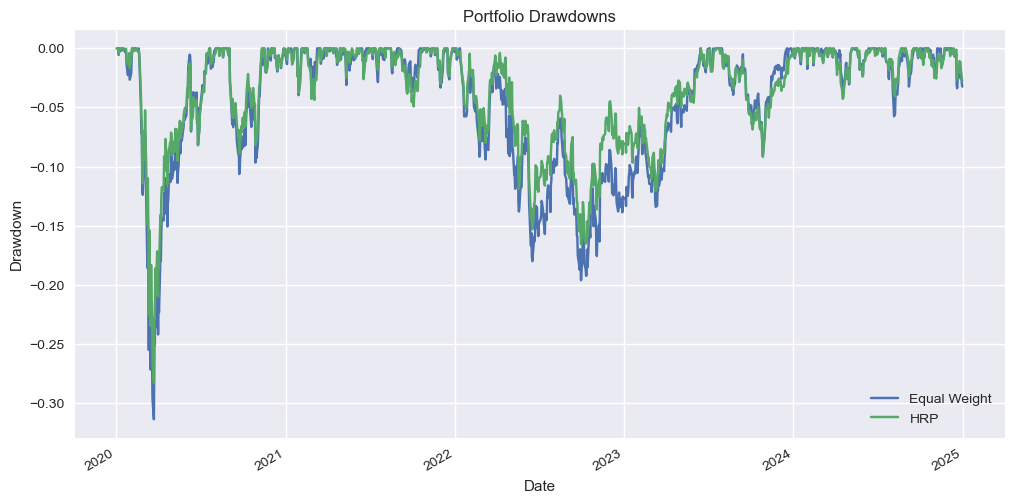

In [36]:
fig, ax = plt.subplots(figsize=(12, 6))

drawdowns.plot(ax=ax)

ax.set_title("Portfolio Drawdowns")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")

plt.show()

## Risk Contribution

The contribution of each asset to total portfolio risk is examined in order to understand how the allocation distributes volatility across the portfolio. This provides an additional view of portfolio concentration beyond the portfolio weights alone.

In [37]:
portfolio_covariance = covariance_matrix.values

hrp_weight_vector = hrp_weights.values.reshape(-1, 1)

portfolio_variance = (
    hrp_weight_vector.T
    @ portfolio_covariance
    @ hrp_weight_vector
)[0, 0]

marginal_risk = (
    portfolio_covariance
    @ hrp_weight_vector
) / np.sqrt(portfolio_variance)

risk_contribution = (
    hrp_weight_vector.flatten()
    * marginal_risk.flatten()
)

risk_contribution = pd.Series(
    risk_contribution,
    index=hrp_weights.index
)

risk_contribution

GOOGL    0.001072
AAPL     0.000580
MSFT     0.000734
AMZN     0.000643
META     0.000410
BAC      0.000505
JPM      0.000354
CVX      0.000515
XOM      0.000343
HD       0.001225
WMT      0.001732
PFE      0.000577
JNJ      0.001104
KO       0.000930
PG       0.001527
dtype: float64

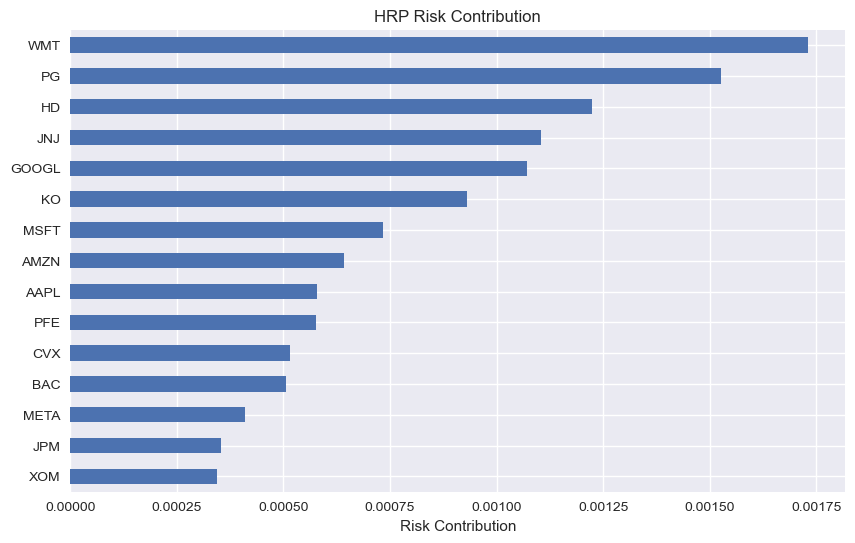

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))

risk_contribution.sort_values().plot(
    kind="barh",
    ax=ax
)

ax.set_title("HRP Risk Contribution")
ax.set_xlabel("Risk Contribution")

plt.show()

## Summary

The notebook explored the use of PCA, hierarchical clustering, and Hierarchical Risk Parity for portfolio construction and diversification analysis. The results illustrate how correlation structure and latent market relationships can be incorporated into a risk-based allocation framework without relying on direct covariance matrix inversion.